<h2><center><b> El espacio muestral asociado a un experimento aleatorio </b><center><h2>

Todos hemos realizada lanzamiento de monedas para definir la solucion a la problematica o para pasar el rato entre parientes; pero para este archivo lo veremos como parte de una **experimento aleatorio (E.A.)**. Consideremos que vamos a lanzar 2 monedas de forma honesta,dichos resultados estara anota en una pareja ordenada.....

El espacio muestral $\Omega$ del experimento aleatorio que esta compuesto por todas las parejas ordenadas $(i,j)$ que lo definiremos como:

$$ \Omega = \{ (i,j) \mid 1 \leq i,j \leq 6 \} $$

y sabemos que $\# \Omega = 6^2 = 36$

In [ ]:
# Usamos itertools
from itertools import product

# vamos a generar el espacio muestral del E.A.
Omega = set(product([1,2,3,4,5,6], repeat = 2))
Omega

{(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6)}

In [ ]:
# guardamos la cardinalidad de nuestro omega
card_Omega = len(Omega)
card_Omega

36

Ya con lo anterior, podemos ver que evento queremos analizar y hay uno que es clasico para los estudiantes...

Sea $S_n$ el evento "La suma de los dados en $n$". Esto es:
$$ S_n = \{(i,j) \in \Omega: i+j = n\}. $$

In [ ]:
# definimos la funcion que se encargue de ver los caso que genere Sn dado nuestro omega
def S(n):
    Sn = {(i,j) for i in range(1,7) for j in range(1,7) if i+j==n}
    return Sn

Podemos ver algunos ejemplos de nuestra funcion creada...

In [ ]:
print(S(9))

{(6, 3), (4, 5), (5, 4), (3, 6)}


In [ ]:
print(S(12))

{(6, 6)}


<h2><center><b> La variable aleatoria asociada a $S_n$ </b><center><h2>

Recordemos que una variable aleatoria real $X$, es una función que $ X : \Omega \to \mathbb{R} $. Antes ver como es **la funcion de masa de probabilidad** tenemos que crera algunas cosas...

In [ ]:
# Vamos a crear una funcion que se encargue de definir la probabilidad de cualquier evento en el espacio muestral.

# usaremos Fraction
from fractions import Fraction

def P(A):
    P = Fraction(len(A), len(Omega))
    return P

In [ ]:
# Vamos a definir un diccionario llamada "S" que almacene nuestro (i,j) pares ordenados y los valores de su suma
S = {(i,j) : i+j for i,j in Omega}
S

{(3, 4): 7,
 (4, 3): 7,
 (3, 1): 4,
 (5, 4): 9,
 (4, 6): 10,
 (5, 1): 6,
 (2, 2): 4,
 (1, 6): 7,
 (2, 5): 7,
 (1, 3): 4,
 (6, 2): 8,
 (6, 5): 11,
 (4, 2): 6,
 (4, 5): 9,
 (3, 3): 6,
 (5, 6): 11,
 (3, 6): 9,
 (5, 3): 8,
 (2, 4): 6,
 (1, 2): 3,
 (2, 1): 3,
 (1, 5): 6,
 (6, 1): 7,
 (6, 4): 10,
 (3, 2): 5,
 (4, 1): 5,
 (3, 5): 8,
 (5, 2): 7,
 (4, 4): 8,
 (5, 5): 10,
 (1, 1): 2,
 (1, 4): 5,
 (2, 3): 5,
 (2, 6): 8,
 (6, 6): 12,
 (6, 3): 9}

Como lo observamos en el diccionario cumple con los caso pero forma desordenada y repetitiva, por lo que haremos uso de otras paqueterias para resolver este asunto....

In [ ]:
# Usaremos defaultdict (se trata de agrupar las combinaciones por suma)
from collections import defaultdict

dS = defaultdict(set)   # guardamos en una variable el comando anterior

In [ ]:
# Vamos a recorrer sobre los elementos en S y dS hara la agrupacion
for i,j in S.items():
    dS[j].add(i)

In [ ]:
S_n = sorted(dS.items())
list(S_n)      # Visualizamos nuestro dS ya ordenamos

[(2, {(1, 1)}),
 (3, {(1, 2), (2, 1)}),
 (4, {(1, 3), (2, 2), (3, 1)}),
 (5, {(1, 4), (2, 3), (3, 2), (4, 1)}),
 (6, {(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)}),
 (7, {(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)}),
 (8, {(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)}),
 (9, {(3, 6), (4, 5), (5, 4), (6, 3)}),
 (10, {(4, 6), (5, 5), (6, 4)}),
 (11, {(5, 6), (6, 5)}),
 (12, {(6, 6)})]

Una vez listo nuestro diccionario **dS**; podemos establecer la probabilidad que corresponde a salidad de nuestra $S_{n}$ que es en si nuestra **V.A.**....

In [ ]:
# LeyS sera un diccionario las probabilidades; usaremos la funcion "P(A)" donde en este caso A sera nuestro conjunto de pares en cada caso i...

leyS = {i : P(A) for i, A in S_n }
leyS

{2: Fraction(1, 36),
 3: Fraction(1, 18),
 4: Fraction(1, 12),
 5: Fraction(1, 9),
 6: Fraction(5, 36),
 7: Fraction(1, 6),
 8: Fraction(5, 36),
 9: Fraction(1, 9),
 10: Fraction(1, 12),
 11: Fraction(1, 18),
 12: Fraction(1, 36)}

Con el resultado anterior vamos a definir ahora si la funcion de probabilidad...

Sabemos que la función de masa de una V.A. discreta $X$, se define como sigue:

$$ f_X(x) = \begin{cases}
                \mathbb{P}(X = x), \quad \text{si } x\in R_{X} \\ 0, \quad \text{e.o.c}
            \end{cases} $$

donde $R_X$ es el rango de la V.A. $X$.

Para nuestro evento $S_n$, se tiene la siguiente V.A.:

$$ S : \Omega \to \{2,3,4,5,6,7,8,9,10,11,12\}$$

Sea $S$ una $V.A.$ discreta tal que $R_S = \{ 2,3,4,5,6,7,8,9,10,11,12 \}$, entonces:

$$ f_X(x) = \begin{cases} \frac{1}{36}, \quad \text{si } x = 2  \\\\
                          \frac{1}{18}, \quad \text{si } x = 3  \\\\
                          \frac{1}{12}, \quad \text{si } x = 4  \\\\
                          \frac{1}{9}, \quad \text{si } x = 5  \\\\
                          \frac{5}{36}, \quad \text{si } x = 6  \\\\
                          \frac{1}{6}, \quad \text{si } x = 7  \\\\
                          \frac{5}{36}, \quad \text{si } x = 8 \\\\
                          \frac{1}{9}, \quad \text{si } x = 9  \\\\
                          \frac{1}{12}, \quad \text{si } x = 10  \\\\
                          \frac{1}{18}, \quad \text{si } x = 11  \\\\
                          \frac{1}{36}, \quad \text{si } x = 12  \\\\
                          0, \quad \text{e.o.c}
            \end{cases} $$

ya teniendo esta definicion, podemos ver como se comporta la grafica de la funcion de probabilidad, pero algunos detalles a resolver....

In [ ]:
import pandas as pd       # Importamos la libreria Pandas (dedicada a la generacion de tablas,series y su manipulacion en Python)

ley_S = pd.Series(leyS)     # Creamos una serie con los datos de "Ley_S" y lo ordenamos
ley_S.sort_index()

,0
2,1/36
3,1/18
4,1/12
5,1/9
6,5/36
7,1/6
8,5/36
9,1/9
10,1/12
11,1/18


In [ ]:
# LeyS(i) sera una funcion que devuelve la probabilidad de obtener la suma en i, si está en el rango S
def leyS(i):
    if i in range(2,13):
        x = ley_S[i]      # la serie anterior
    else:
        x = 0       # si no está en el rango me devuelve cero
    return x

Para la grafica, vamos a crear 2 variables que las ocuparemos como los ejes de la grafica

In [ ]:
import numpy as np      # Importar la liberia

# Vamos a crear el rango de S en lista
rango_S = [k for k in range(2,13)]

# Obtenemos la probabilidad de cada suma por la funcion "LeyS(i)" en otra lista
p_k = [float(leyS(k)) for k in rango_S]

ya teniedo los ejes, vamos a ver codificar la serie en *un dataframe* (por practicidad), recorddemos como funciona los parametros...

Para creamos un **DataFrame** con:

*   **Primera entrada:** son los valores que deseamos en tabla.
*   **Segunda entrada:** son los nombres que sean los indices de la tablas
*   **Tercera entrada:** son los nombres que sean las columnas de la tabla

In [ ]:
# "list()" crea una lista e "zip()" forma pares ordenados de acuerdo a las lista que agregues
lS = pd.DataFrame(list(zip(rango_S, p_k)), index = [f"S_{i}" for i in range(2,13)], columns = ['rango','densidad'])
lS

,rango,densidad
S_2,2,0.027778
S_3,3,0.055556
S_4,4,0.083333
S_5,5,0.111111
S_6,6,0.138889
S_7,7,0.166667
S_8,8,0.138889
S_9,9,0.111111
S_10,10,0.083333
S_11,11,0.055556


<Axes: xlabel='rango'>

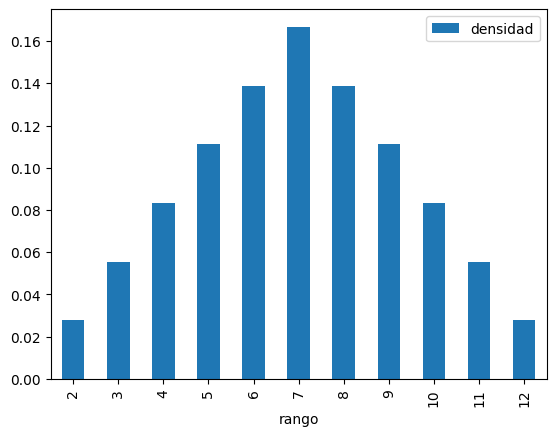

In [ ]:
# Creamos la grafica de barras usando los nombres de las columnas del dataframe anterior..
lS.plot.bar( x= 'rango', y = 'densidad')